03 was a short smoke test. Here we do a proper baseline with logging via helpers/utils.py then try a few hyperparameter changes on val.

In [1]:
import sys
from pathlib import Path
from ultralytics import YOLO

In [2]:
PROJECT_ROOT = Path("..").resolve()
sys.path.insert(0, str(PROJECT_ROOT))

In [3]:
from helpers.utils import set_seed, yolo_log_kwargs
set_seed(42)

DATA_YAML = PROJECT_ROOT / "data" / "dataset.yaml"
WEIGHTS = PROJECT_ROOT / "models" / "yolo26n" / "yolo26n.pt"
RUNS = PROJECT_ROOT / "models" / "runs"

In [ ]:
# model = YOLO(str(WEIGHTS))

Same pretrained YOLO26n but longer training. Recall matters more than precision for early fire so we watch recall and mAP@0.5 on val.

In [ ]:
# results = model.train(
#     data=str(DATA_YAML),
#     epochs=50,
#     imgsz=640,
#     batch=16,
#     device=0,
#     seed=42,
#     close_mosaic=10,  # keep mosaic on until the last 10 epochs
#     **yolo_log_kwargs(RUNS, "yolo26n_baseline", save_period=5),
# )

New https://pypi.org/project/ultralytics/8.4.116 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.56  Python-3.11.15 torch-2.12.0+cu130 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\Arda\Desktop\Engineering\early-fire-detection\data\dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=

Best val (all): P=0.943, R=0.900, mAP50=0.944, mAP50-95=0.645.

Fire is a bit easier (R=0.916, mAP50=0.958) than smoke (R=0.883, mAP50=0.930)

In [4]:
results = YOLO(str(RUNS / "yolo26n_baseline" / "weights" / "best.pt"))
metrics = results.val(
    data=str(DATA_YAML),
    split="val",
    plots=True,
    project=str(RUNS),
    name="yolo26n_baseline_val",
    exist_ok=True,
)

Ultralytics 8.4.56  Python-3.11.15 torch-2.12.0+cu130 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
YOLO26n summary (fused): 122 layers, 2,375,226 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 1656.7991.1 MB/s, size: 464.6 KB)
val: Scanning C:\Users\Arda\Desktop\Engineering\early-fire-detection\data\val\labels.cache... 1300 images, 33 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1300/1300  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 82/82 14.1it/s 5.8s0.2s
                   all       1300       1580      0.942      0.898      0.945      0.645
                  fire        894        963      0.948      0.912      0.958      0.687
                 smoke        574        617      0.936      0.884      0.933      0.604
Speed: 0.7ms preprocess, 1.6ms inference, 0.0ms loss, 0.1ms postprocess per image
Results saved to C:\Users\Arda\Desktop\Engineering\early-fire-detection\models\

In [5]:
from helpers.utils import f1_score, f2_score

print(f"Precision: {metrics.box.mp}")
print(f"Recall:    {metrics.box.mr}")
print(f"mAP@0.5:   {metrics.box.map50}")
print(f"mAP@0.5:95:{metrics.box.map}")

p, r = float(metrics.box.mp), float(metrics.box.mr)
print(f"F1: {f1_score(p, r)}")
print(f"F2: {f2_score(p, r)}")

Precision: 0.9424217116746282
Recall:    0.8977324837912111
mAP@0.5:   0.9454412196956172
mAP@0.5:95:0.6453898705019173
F1: 0.9195344456297054
F2: 0.9063280199335106


In [6]:
import matplotlib.pyplot as plt
%matplotlib inline

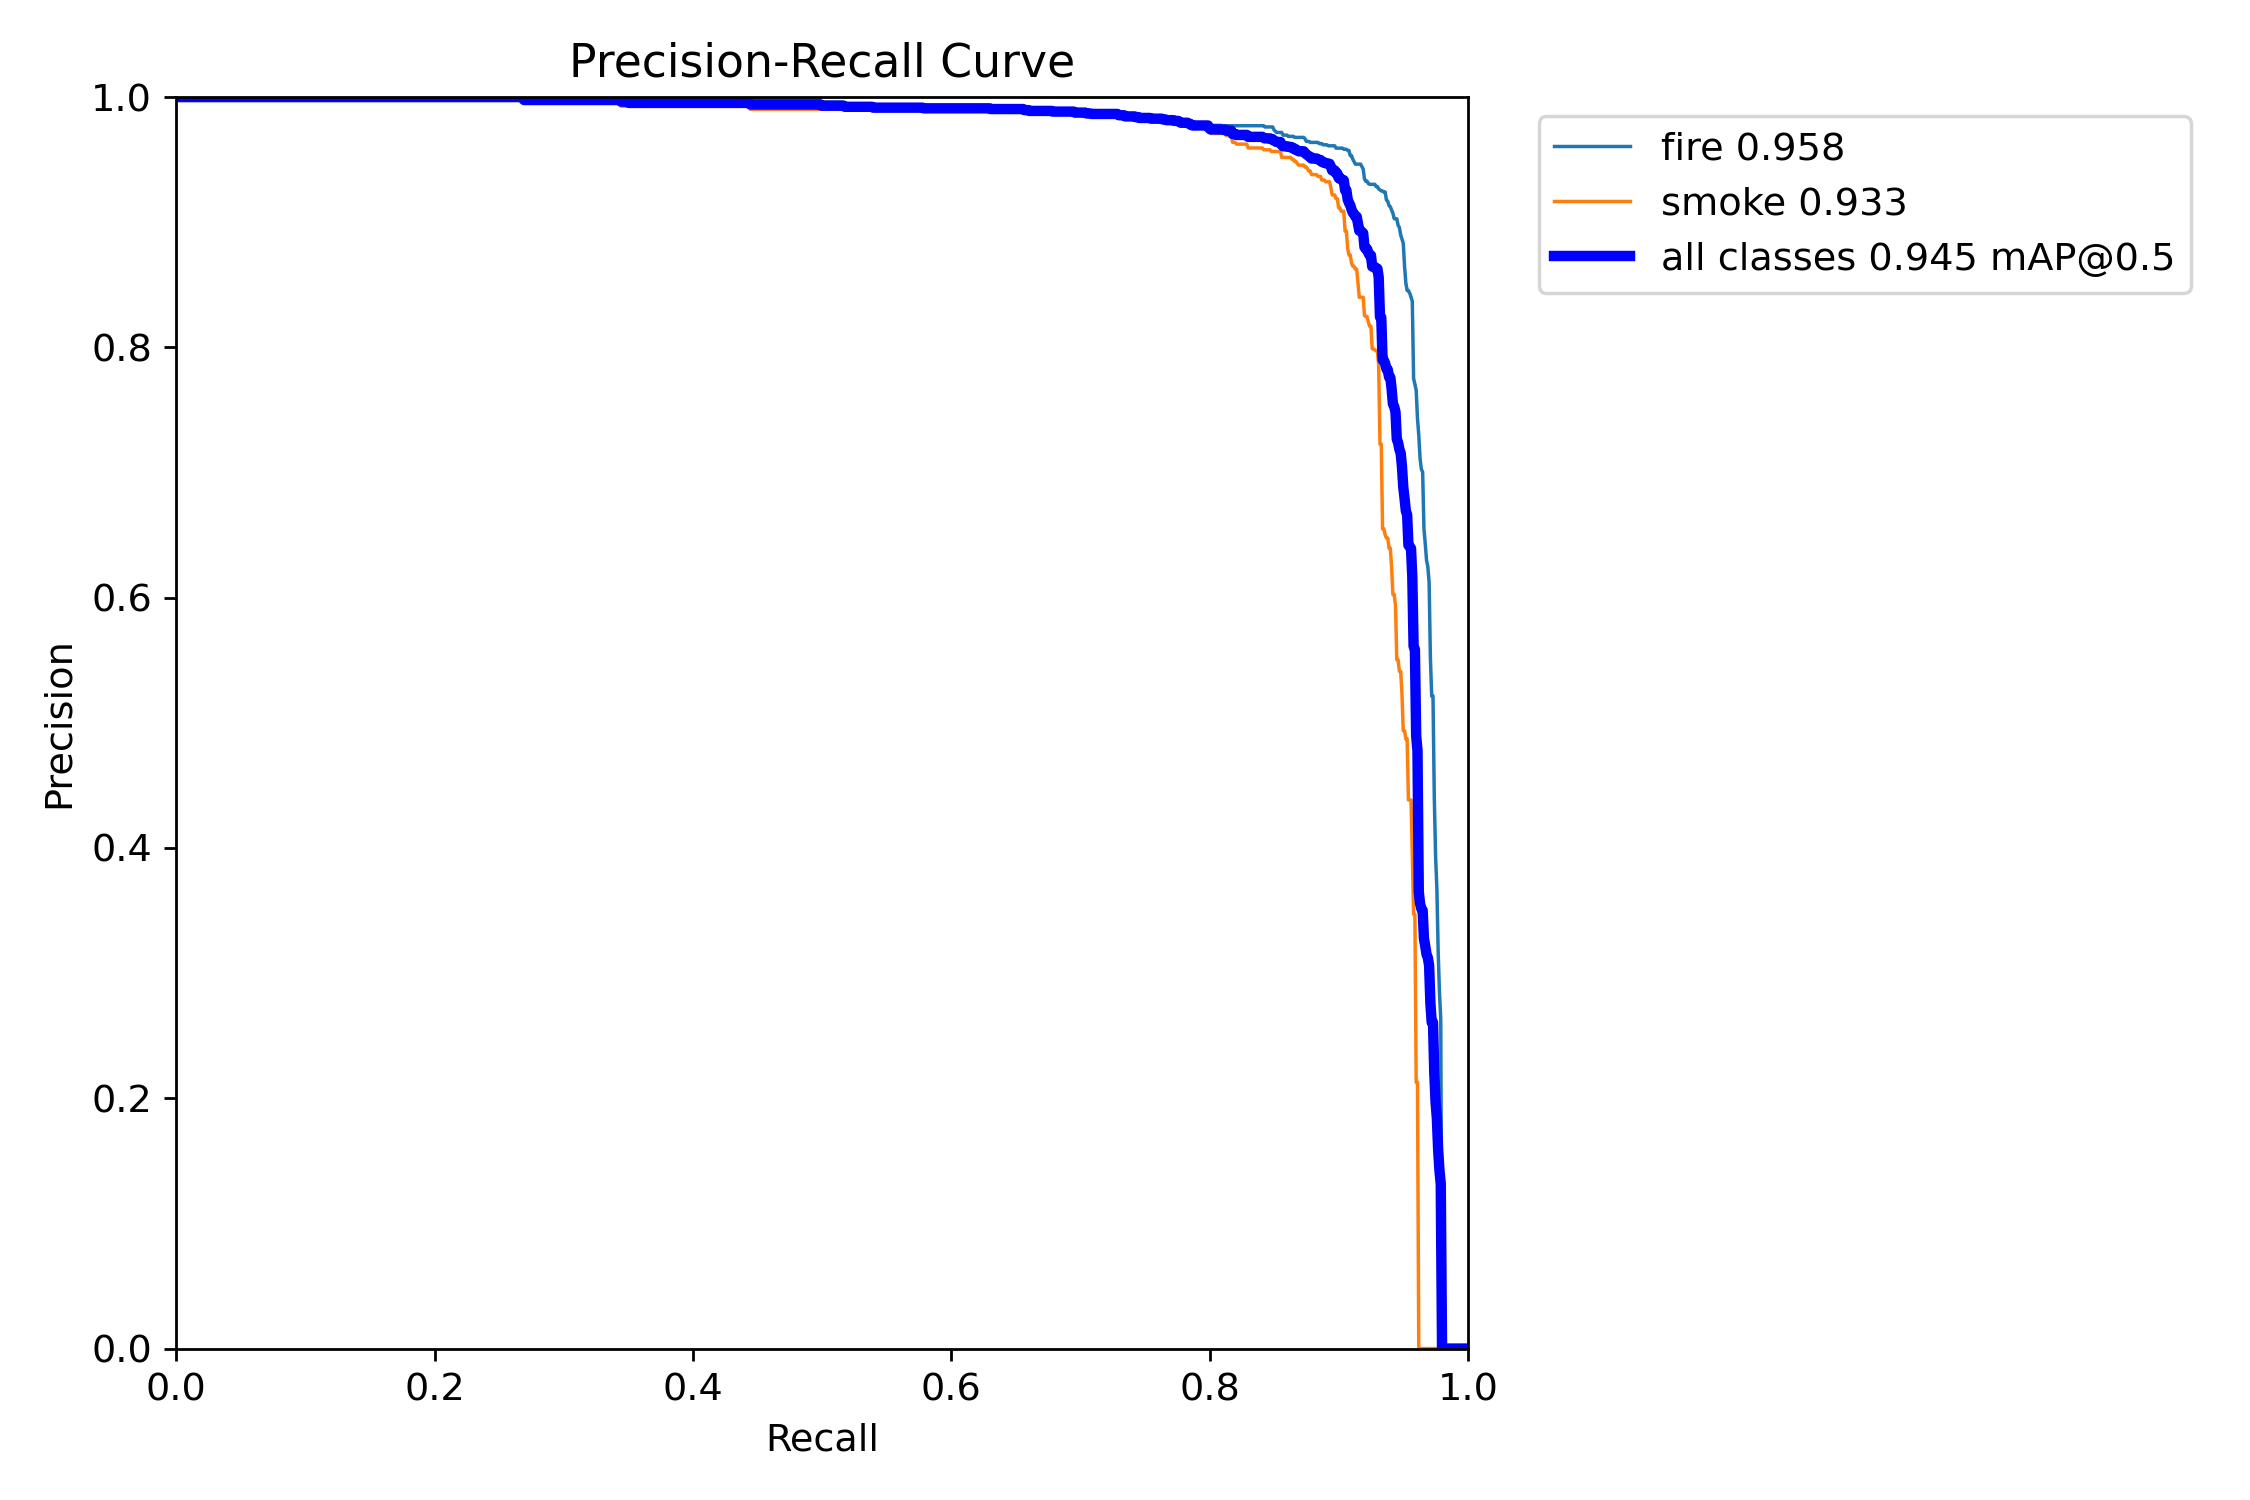

In [7]:
from IPython.display import Image, display
pr_path = RUNS / "yolo26n_baseline_val" / "BoxPR_curve.png"
display(Image(filename=str(pr_path)))